In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df_dict = {}
for csv in os.listdir("data/MDM2_Breaker/processed"):
    if not csv.endswith(".csv"):
        continue 
    if not csv.startswith("GraphDTA-"):
        continue 

    file_name = csv.split("_")[0]
    print(file_name)
    df_dict[file_name] = pd.read_csv(os.path.join("data/MDM2_Breaker/processed", csv))



GraphDTA-GCN-Graph
GraphDTA-GAT-Sequence
GraphDTA-GAT-Graph
GraphDTA-GINE-Sequence
GraphDTA-GCN-Sequence


In [3]:
df_dict["XGBoost-Baseline"] = pd.read_csv("data/MDM2_Breaker/processed/xgboost_benchmark_random_seed_results.csv")

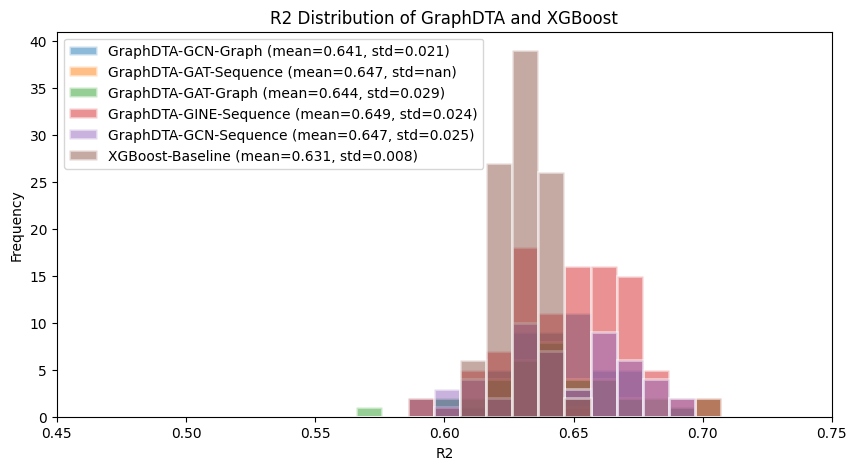

In [4]:
_, ax = plt.subplots(figsize=(10, 5))

for file_name, df in df_dict.items():
    col_name = "r2" if file_name != "XGBoost-Baseline" else "test_r2"
    mean = df[col_name].mean()
    std = df[col_name].std()
    df[col_name].hist(
        bins=np.linspace(0, 1, 100),
        ax=ax,
        label=f"{file_name} (mean={mean:.3f}, std={std:.3f})",
        alpha=0.5,
        linewidth=2,
        edgecolor="white",
    )

ax.legend()
ax.grid(False)
ax.set_xlim(0.45, 0.75)
ax.set_xlabel("R2")
ax.set_ylabel("Frequency")
ax.set_title("R2 Distribution of GraphDTA and XGBoost")
ax.legend()


/var/folders/wt/5vc39b651nn6m5wm29j25dk80000gn/T/ipykernel_24002/3936473698.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/var/folders/wt/5vc39b651nn6m5wm29j25dk80000gn/T/ipykernel_24002/3936473698.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([labels[t.get_text()] for t in ax.get_xticklabels()])


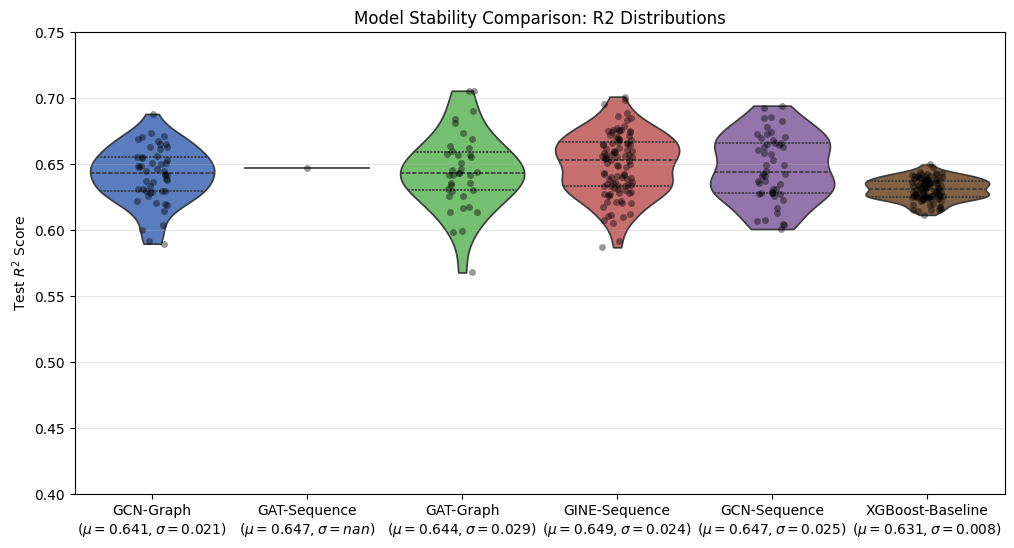

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Consolidate data into a single DataFrame for Seaborn
plot_data = []
for model_name, df in df_dict.items():
    # Handle the column name difference
    col_name = "r2" if "r2" in df.columns else "test_r2"
    
    # Create a temporary list of dictionaries for this model's runs
    for score in df[col_name]:
        plot_data.append({
            "Model": model_name,
            "R2 Score": score
        })

df_viz = pd.DataFrame(plot_data)

# 2. Calculate stats for the legend
stats = df_viz.groupby("Model")["R2 Score"].agg(['mean', 'std'])
labels = {
    model: f"{model.split('GraphDTA-')[-1]}\n($\mu={row['mean']:.3f}, \sigma={row['std']:.3f}$)" 
    for model, row in stats.iterrows()
}

# 3. Create the Violin Plot
plt.figure(figsize=(12, 6))
ax = sns.violinplot(
    data=df_viz, 
    x="Model", 
    y="R2 Score", 
    palette="muted", 
    inner="quartile",  # Shows quartiles inside the violin
    cut=0              # Limits the violin range to observed data (prevents impossible tails)
)

# Overlay the actual data points (jittered)
sns.stripplot(
    data=df_viz, 
    x="Model", 
    y="R2 Score", 
    color="black", 
    alpha=0.4, 
    jitter=True, 
    ax=ax
)

# 4. Formatting
ax.set_xticklabels([labels[t.get_text()] for t in ax.get_xticklabels()])
ax.set_ylim(0.40, 0.75) # Adjust based on your specific range
ax.grid(axis='y', alpha=0.3)
plt.title("Model Stability Comparison: R2 Distributions")
plt.ylabel("Test $R^2$ Score")
plt.xlabel("") # Remove redundant x-label
plt.show()